# Mall Customer Segmentation

The goal of this project is to segment customers based on their characteristics in order to support business decision-making and targeted marketing strategies.

Clustering techniques will be used to identify homogeneous groups of customers with similar behavior, focusing in particular on spending patterns.

## Environment and Library Setup

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## Data

The dataset is loaded from an external Excel file containing customer information such as demographics and purchasing behavior.

A first inspection of the dataset is performed to understand its structure and available features.

In [160]:
data = pd.read_excel('Mall Customers.xlsx')
data.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


The dataset contains 200 observations and 7 features, including both numerical and categorical variables.

Key columns include:
- **CustomerID**: unique identifier, it will be removed in the preprocessing section because it does not carry meaningful information for clustering.
- **Gender, Education, Marital Status**: categorical features
- **Age, Annual Income, Spending Score**: numerical features

No missing values are present, and data types are consistent with expectations.

## EDA

Before proceeding with the analysis, the dataset is checked for:
- missing values
- duplicated rows

In [162]:
print("Number of missing values:", data.isnull().sum().sum())

Number of missing values: 0


In [163]:
print(f"Number of duplicated rows: {data.duplicated().sum()}")

Number of duplicated rows: 0


This ensures that no immediate data cleaning is required.

### Statistical summary

In [164]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Descriptive statistics provide an overview of the distribution of numerical variables.

Key observations:
- **Age** ranges from young adults to older customers
- **Annual Income** shows a wide spread, indicating diverse economic profiles
- **Spending Score** is evenly distributed, suggesting variability in customer behavior

These variables will play a central role in the clustering phase.

### Distribution analysis

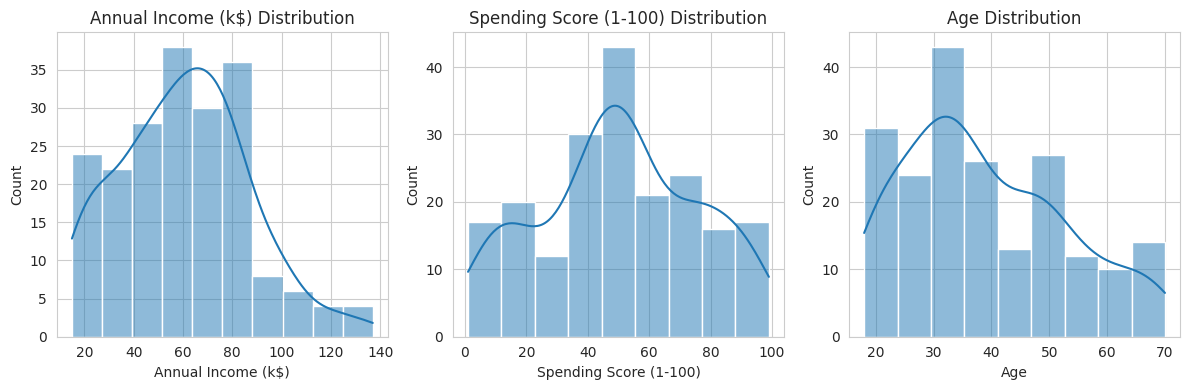

In [165]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data['Annual Income (k$)'], kde=True, ax=axes[0])
axes[0].set_title('Annual Income (k$) Distribution')
sns.histplot(data['Spending Score (1-100)'], kde=True, ax=axes[1])
axes[1].set_title('Spending Score (1-100) Distribution')
sns.histplot(data['Age'], kde=True, ax=axes[2])
axes[2].set_title('Age Distribution')
plt.tight_layout()
plt.show()

The distributions of key numerical variables are analyzed:

- **Annual Income**: relatively spread across different ranges
- **Spending Score**: shows variability, useful for segmentation
- **Age**: slightly concentrated around middle-age groups

Understanding these distributions helps identify potential clusters and detect anomalies.

### Relationship Between Income and Spending

The relationship between **Annual Income** and **Spending Score** is visualized using a scatter plot.

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

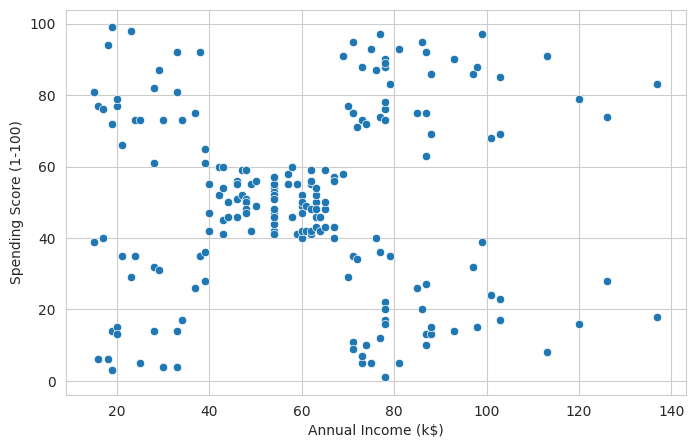

In [166]:
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=data)

These visible groupings suggest that customers exhibit distinct spending behaviors despite similar income levels, making segmentation particularly valuable for targeted marketing strategies.

This relationship will be the foundation for the clustering model.

### Correlation Analysis

<Axes: >

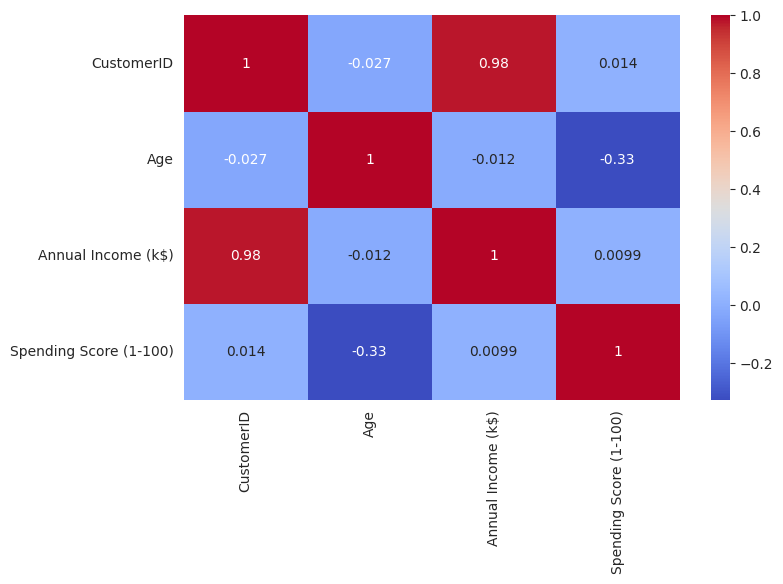

In [167]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

A correlation matrix is used to evaluate relationships between numerical variables.

No strong linear correlations are observed, reinforcing the need for clustering techniques to uncover hidden structures in the data.

Based on the exploratory analysis, **Annual Income** and **Spending Score** appear to be the most relevant features for customer segmentation.

The next step will involve:
- feature selection
- data scaling
- application of clustering algorithms

## Preprocessing

In this phase, the dataset is prepared for clustering by:
- removing irrelevant features
- selecting relevant variables
- scaling numerical data

The goal is to create a clean and well-structured dataset suitable for clustering algorithms.

### Removing Irrelevant Features

In [168]:
data = data.drop(columns=['CustomerID'])

The **CustomerID** column is removed as it does not contribute to the clustering process.

### Feature Selection

In [169]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

Based on the exploratory data analysis, the following features are selected:

- **Annual Income (k$)**
- **Spending Score (1-100)**

These variables show clear patterns and allow effective customer segmentation, as well as intuitive visualization in two dimensions.

### Scaling

In [170]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Clustering algorithms such as K-Means are distance-based and therefore sensitive to the scale of the data.

To ensure that all features contribute equally, the data is standardized using **StandardScaler**, resulting in variables with:
- mean = 0
- standard deviation = 1

### Effect of Feature Scaling

The following plots show the data distribution before and after scaling.

Since clustering algorithms rely on distance, scaling ensures that both features contribute equally to the model, preventing variables with larger magnitudes from dominating the results.

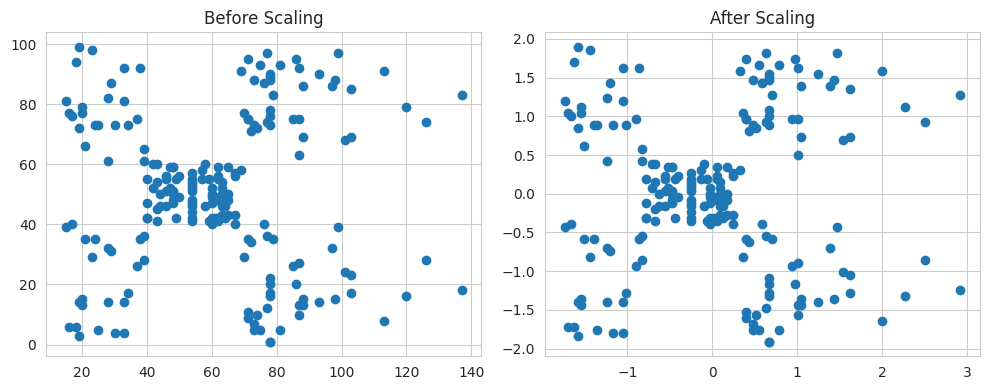

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].scatter(X.iloc[:,0], X.iloc[:,1])
axes[0].set_title("Before Scaling")

axes[1].scatter(X_scaled[:,0], X_scaled[:,1])
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

After scaling, the feature space becomes standardized, making it more suitable for distance-based clustering algorithms such as K-Means.

## Clustering

### Choosing the Number of Clusters

Before applying clustering algorithms, the optimal number of clusters is determined using the Elbow Method.

This method evaluates how the within-cluster variance decreases as the number of clusters increases.

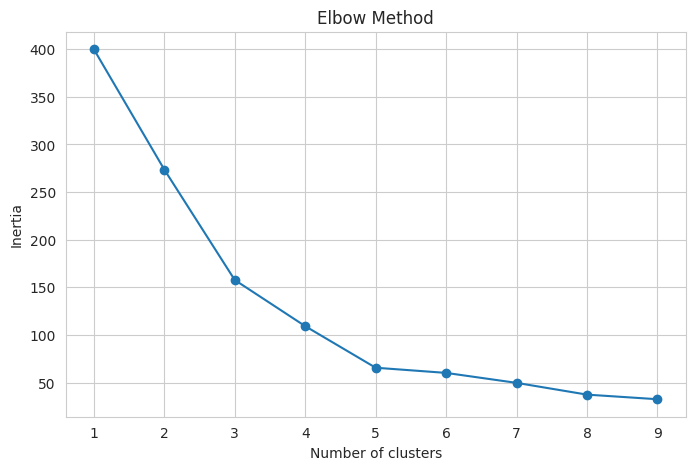

In [172]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

The elbow point appears around **k = 5**, where the rate of decrease in inertia slows down.

This suggests that 5 clusters provide a good balance between model complexity and explanatory power.

### Clustering models

Different clustering algorithms are applied and compared to evaluate how customer segments are identified under different assumptions.

The following models are considered:
- K-Means (centroid-based)
- Agglomerative Clustering (hierarchical)
- DBSCAN (density-based)

In [173]:
def evaluate_clustering(X, labels):
    if len(set(labels)) > 1:
        return round(silhouette_score(X, labels),4)
    else:
        return -1

In [174]:
results = []

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
results.append(("KMeans", evaluate_clustering(X_scaled, labels_km)))

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X_scaled)
results.append(("Agglomerative", evaluate_clustering(X_scaled, labels_agg)))

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)
results.append(("DBSCAN", evaluate_clustering(X_scaled, labels_db)))

In [175]:
results_df = pd.DataFrame(results, columns=["Model", "Silhouette Score"])
results_df

,Model,Silhouette Score
0,KMeans,0.5547
1,Agglomerative,0.5538
2,DBSCAN,0.3504


The models are compared using the silhouette score, which measures how well-separated the clusters are.

While K-Means and Agglomerative Clustering produce well-defined clusters, DBSCAN shows lower performance, likely due to the relatively uniform density of the dataset, which makes it difficult to identify distinct dense regions.

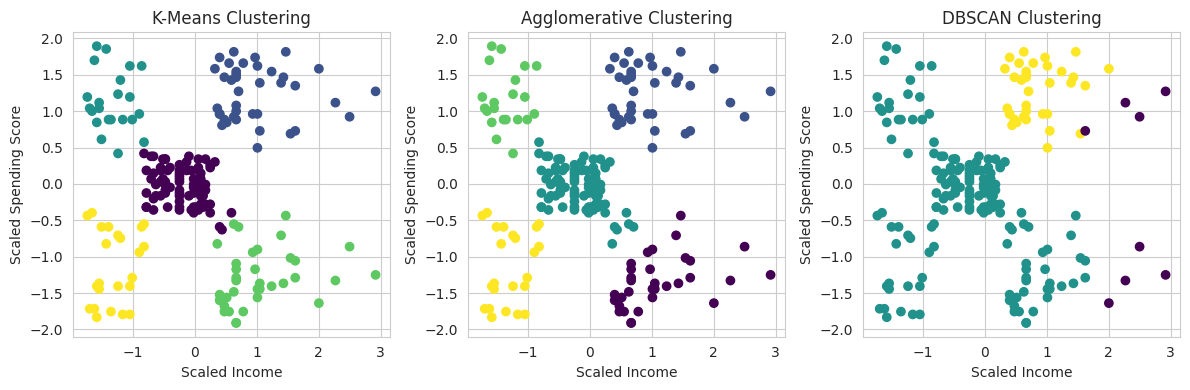

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# K-Means Plot
axes[0].scatter(X_scaled[:,0], X_scaled[:,1], c=labels_km, cmap='viridis')
axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Scaled Income")
axes[0].set_ylabel("Scaled Spending Score")

# Agglomerative Clustering Plot
axes[1].scatter(X_scaled[:,0], X_scaled[:,1], c=labels_agg, cmap='viridis')
axes[1].set_title("Agglomerative Clustering")
axes[1].set_xlabel("Scaled Income")
axes[1].set_ylabel("Scaled Spending Score")

# DBSCAN Plot
axes[2].scatter(X_scaled[:,0], X_scaled[:,1], c=labels_db, cmap='viridis')
axes[2].set_title("DBSCAN Clustering")
axes[2].set_xlabel("Scaled Income")
axes[2].set_ylabel("Scaled Spending Score")

plt.tight_layout()
plt.show()

K-Means is selected as the final model due to its strong cluster separation, simplicity, and high interpretability, making it particularly suitable for business applications such as customer segmentation.

## Evaluation

The final K-Means model is evaluated using the silhouette score, which measures how similar observations are within the same cluster compared to other clusters.

A higher silhouette score indicates better-defined and more separated clusters.

In [177]:
final_score = silhouette_score(X_scaled, labels_km)

print(f"Final K-Means Silhouette Score: {final_score:.4f}")

Final K-Means Silhouette Score: 0.5547


The obtained silhouette score suggests a good level of cluster separation, indicating that customers are grouped into relatively distinct segments.

## Interpretation

### Cluster summary

In [178]:
data['Cluster'] = labels_km

In [179]:
cluster_names = {
    0: 'Balanced Customers',
    1: 'Premium Customers',
    2: 'Impulse Buyers',
    3: 'Cautious High-Income Customers',
    4: 'Low-Value Customers'}

data['Cluster Name'] = data['Cluster'].map(cluster_names)

In [180]:
cluster_summary = data.groupby('Cluster Name')[
    ['Age',
     'Annual Income (k$)',
      'Spending Score (1-100)']].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster Name,,,
Balanced Customers,42.72,55.30,49.52
Cautious High-Income Customers,41.11,88.20,17.11
Impulse Buyers,25.27,25.73,79.36
Low-Value Customers,45.22,26.30,20.91
Premium Customers,32.69,86.54,82.13


To better understand customer behavior, the average characteristics of each cluster are analyzed.

The clusters reveal different customer profiles based on age, income, and spending behavior.

### Cluster Distribution

The distribution of customers across clusters helps evaluate the balance and relative size of each customer segment.

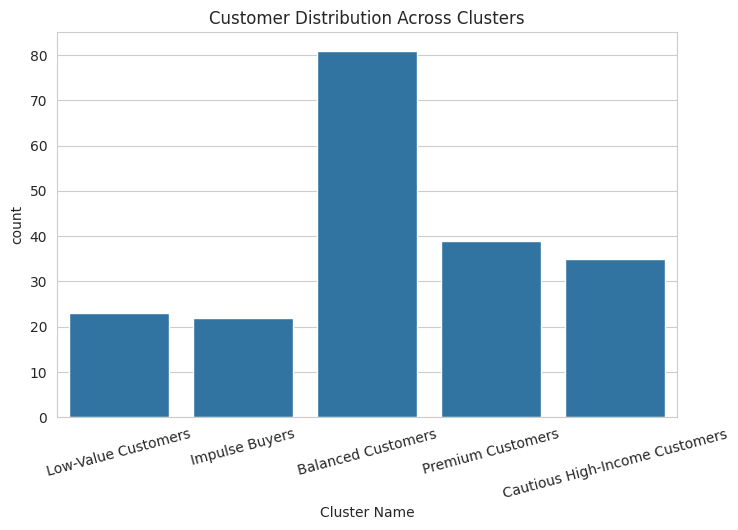

In [181]:
sns.countplot(x='Cluster Name', data=data)

plt.xticks(rotation=15)
plt.title("Customer Distribution Across Clusters")
plt.show()

The identified clusters can be translated into meaningful customer profiles that support marketing and strategic decision-making.

### Business Insights

The clustering analysis reveals five distinct customer segments with different behavioral and economic characteristics.

- **Premium Customers**  
  High income and high spending customers represent the most valuable segment. These customers are ideal targets for premium services, loyalty programs, and personalized marketing campaigns.

- **Cautious High-Income Customers**  
  Despite having high income levels, these customers show relatively low spending behavior. This segment may benefit from engagement strategies and targeted promotions aimed at increasing purchase activity.

- **Impulse Buyers**  
  Customers in this segment exhibit high spending behavior despite lower income levels, suggesting strong engagement and impulsive purchasing tendencies.

- **Low-Value Customers**  
  Low income and low spending customers represent the least profitable segment and may require lower marketing prioritization.

- **Balanced Customers**  
  This group shows moderate income and spending levels, representing stable and average customer behavior.

Overall, the clustering approach provides actionable insights that can support customer segmentation, targeted marketing, and business decision-making.

### Cluster Visualization

The final visualization highlights the customer segments identified by the K-Means algorithm.

Cluster centroids represent the center of each segment and help summarize the overall characteristics of customer groups.

In [182]:
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

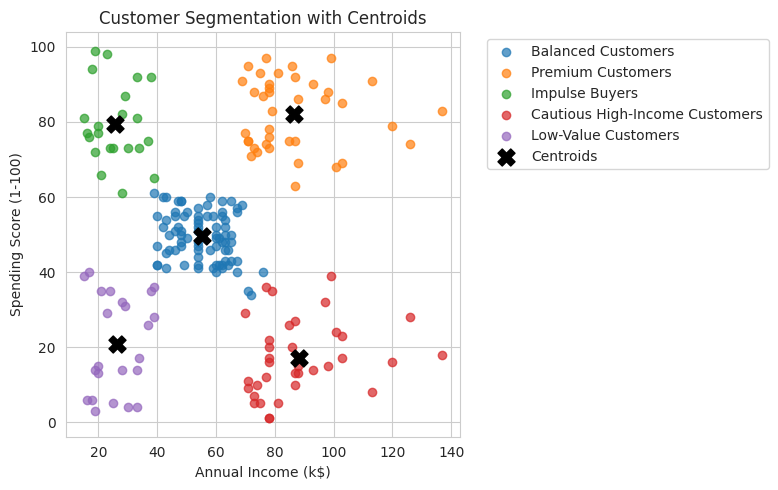

In [183]:
for cluster_id, cluster_name in cluster_names.items():
    cluster_data = data[data['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                label=cluster_name,
                alpha=0.7)

plt.scatter(centers_original[:,0],
            centers_original[:,1],
            s=150,
            c='black',
            marker='X',
            label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation with Centroids")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Conclusion

This project explored customer segmentation using clustering techniques applied to mall customer data.

After comparing multiple clustering algorithms, K-Means was selected as the final model due to its strong performance and interpretability.

The analysis successfully identified distinct customer groups with different spending behaviors and income profiles, demonstrating how clustering can support business intelligence and targeted marketing strategies.